In [2]:
import sys
import importlib
import logomaker
import pandas as pd

sys.path.append(".")
from src.cstarters import ml_utils

importlib.reload(ml_utils)

from src.cstarters.ml_utils import load_dataset


In [3]:
def logo_sequence(sequence, positions):
    output_sequence = ""
    for i in positions:
        output_sequence += sequence[i]
    return output_sequence


In [4]:
df = load_dataset(path='cstarters_dataset.csv')
df

,cs_accession,starter_beta_hydroxylation,starter_category,aligned_sequence,ncbi_organism_genus
1,CS0000126,NaN,SCFA,----------------------------------------------...,Streptomyces
3,CS0000291,FALSE,LCFA,------------------M----L------------E---------...,Streptomyces
4,CS0000296,NaN,AR,------------------M----F------------V---------...,Streptomyces
5,CS0000305,TRUE,LCFA,------------------P----A------------V----A----...,Pseudomonas
6,CS0000306,FALSE,LCFA,------------------M----S------------A---------...,Streptomyces
...,...,...,...,...,...
403,CS0002695,NaN,AR,------------------M----T------------K---------...,Bacillus
406,CS0002696,NaN,AR,------------------P----GL--------NSGA---------...,Rhodococcus
408,CS0002697,FALSE,LCFA,----------------------------------------------...,Streptantibioticus
412,CS0002719,TRUE,LCFA,------------------M----I----------------------...,Pseudomonas


In [5]:
aromaticity_important_positions = [96, 98, 347, 350, 818, 884, 924, 936, 986]
hydroxylation_important_positions = [98, 814, 818, 924, 932, 936, 944, 991]

with open('logo_sequences.csv', 'w') as of:
    of.write('cs_accession,starter_beta_hydroxylation,starter_category,aromaticity_important,hydroxylation_important\n')
    for _, row in df.iterrows():
        starter_beta_hydroxylation = str(row['starter_beta_hydroxylation'])
        if starter_beta_hydroxylation in ['nan', 'unknown', '_not_elligible']:
            starter_beta_hydroxylation = ''

        of.write(str(row['cs_accession']) + ',' + starter_beta_hydroxylation + ',' + str(row['starter_category']) + ',')


        of.write(logo_sequence(row['aligned_sequence'], aromaticity_important_positions) + ',')
                                                    
        of.write(logo_sequence(row['aligned_sequence'], hydroxylation_important_positions) + '\n')

## Aromaticity

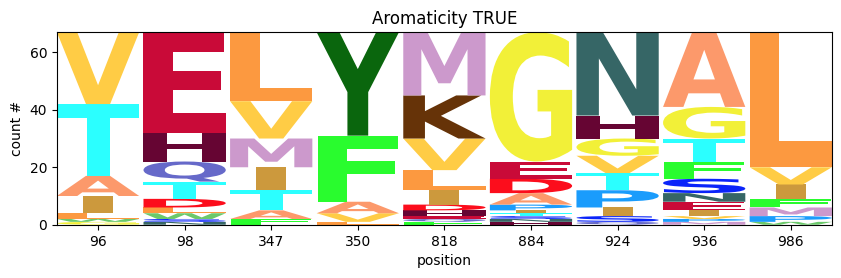

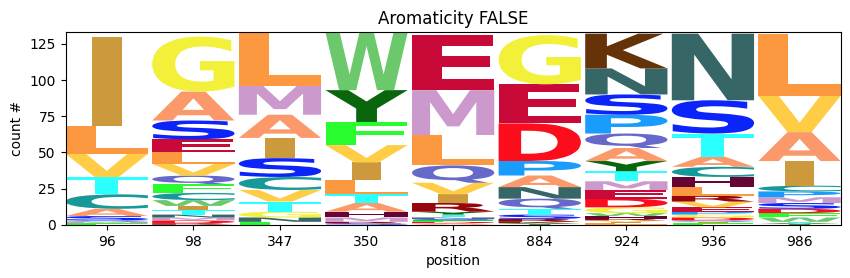

In [6]:
logo_df = pd.read_csv('logo_sequences.csv')

ar_true_df = logomaker.alignment_to_matrix(
    sequences= logo_df[logo_df['starter_category'] == 'AR']['aromaticity_important'],
    to_type='counts',               
    characters_to_ignore='.-X',
)
ar_false_df = logomaker.alignment_to_matrix(
    sequences= logo_df[logo_df['starter_category'] != 'AR']['aromaticity_important'],
    to_type='counts',                
    characters_to_ignore='.-X',
)

logo_ar_true = logomaker.Logo(ar_true_df, color_scheme='skylign_protein')
logo_ar_true.ax.set_xticks(range(len(aromaticity_important_positions)))
logo_ar_true.ax.set_xticklabels(aromaticity_important_positions)
logo_ar_true.ax.set_title('Aromaticity TRUE')
logo_ar_true.ax.set_ylabel('count #')
logo_ar_true.ax.set_xlabel('position')
logo_ar_true.ax.figure.savefig('sequence_logo_images/ar_true_logo.svg', format='svg', bbox_inches='tight')

logo_ar_false = logomaker.Logo(ar_false_df, color_scheme='skylign_protein')
logo_ar_false.ax.set_xticks(range(len(aromaticity_important_positions)))
logo_ar_false.ax.set_xticklabels(aromaticity_important_positions)
logo_ar_false.ax.set_title('Aromaticity FALSE')
logo_ar_false.ax.set_ylabel('count #')
logo_ar_false.ax.set_xlabel('position')
logo_ar_false.ax.figure.savefig('sequence_logo_images/ar_false_logo.svg', format='svg', bbox_inches='tight')


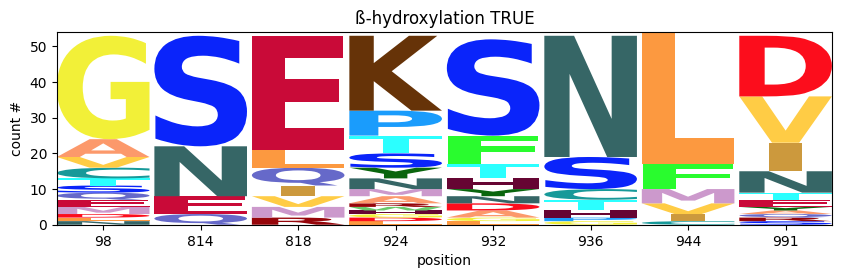

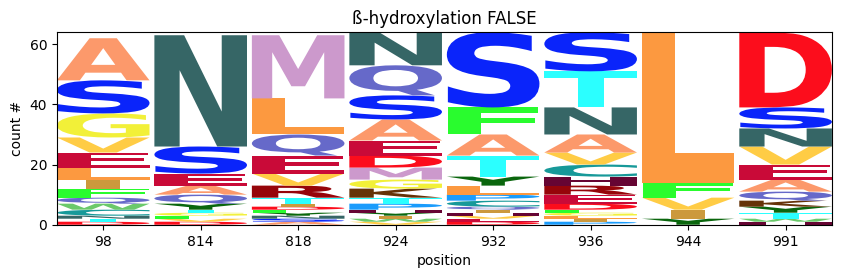

In [7]:
logo_df = pd.read_csv('logo_sequences.csv')

boh_true_df = logomaker.alignment_to_matrix(
    sequences= logo_df[logo_df['starter_beta_hydroxylation'] == True]['hydroxylation_important'],
    to_type='counts',               
    characters_to_ignore='.-X',
)
boh_false_df = logomaker.alignment_to_matrix(
    sequences= logo_df[logo_df['starter_beta_hydroxylation'] == False]['hydroxylation_important'],
    to_type='counts',                
    characters_to_ignore='.-X',
)

logo_boh_true = logomaker.Logo(boh_true_df, color_scheme='skylign_protein')
logo_boh_true.ax.set_xticks(range(len(hydroxylation_important_positions)))
logo_boh_true.ax.set_xticklabels(hydroxylation_important_positions)
logo_boh_true.ax.set_title('ß-hydroxylation TRUE')
logo_boh_true.ax.set_ylabel('count #')
logo_boh_true.ax.set_xlabel('position')
logo_boh_true.ax.figure.savefig('sequence_logo_images/boh_true_logo.svg', format='svg', bbox_inches='tight')

logo_boh_false = logomaker.Logo(boh_false_df, color_scheme='skylign_protein')
logo_boh_false.ax.set_xticks(range(len(hydroxylation_important_positions)))
logo_boh_false.ax.set_xticklabels(hydroxylation_important_positions)
logo_boh_false.ax.set_title('ß-hydroxylation FALSE')
logo_boh_false.ax.set_ylabel('count #')
logo_boh_false.ax.set_xlabel('position')
logo_boh_false.ax.figure.savefig('sequence_logo_images/boh_false_logo.svg', format='svg', bbox_inches='tight')